In [ ]:
import numpy as np
import matplotlib.pyplot as plt


Lx, Ly = 15000, 15000 
nx, ny, nz = 60,60,50 
max_depth1 = 1600  
max_depth2 = 1100  

x_edges = np.linspace(0, Lx, nx + 1)
y_edges = np.linspace(0, Ly, ny + 1)
z_edges = np.linspace(0, max_depth1, nz + 1)

xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
zc = 0.5 * (z_edges[:-1] + z_edges[1:]) 

Xc2d, Yc2d = np.meshgrid(xc, yc, indexing='ij') 

x1, y1 = Lx * 0.3, Ly / 2
R1 = np.sqrt((Xc2d - x1)**2 + (Yc2d - y1)**2)
Rmax1 = 3900
basin1 = max_depth1 * (1 - (R1 / Rmax1)**2)
basin1[R1 > Rmax1] = 0


x2, y2 = Lx * 0.65, Ly / 2
R2 = np.sqrt((Xc2d - x2)**2 + (Yc2d - y2)**2)
Rmax2 = 4500
basin2 = max_depth2 * (1 - (R2 / Rmax2)**2)
basin2[R2 > Rmax2] = 0


basin_depth = np.maximum(basin1, basin2)  


rho_top = -550  
rho_bottom = -850  
density_profile = np.linspace(rho_top, rho_bottom, nz) 


density_contrast = np.zeros((nx, ny, nz))

for k in range(nz):
    z = zc[k]
    for i in range(nx):
        for j in range(ny):
            if z <= basin_depth[i, j]:
                density_contrast[i, j, k] = density_profile[k]




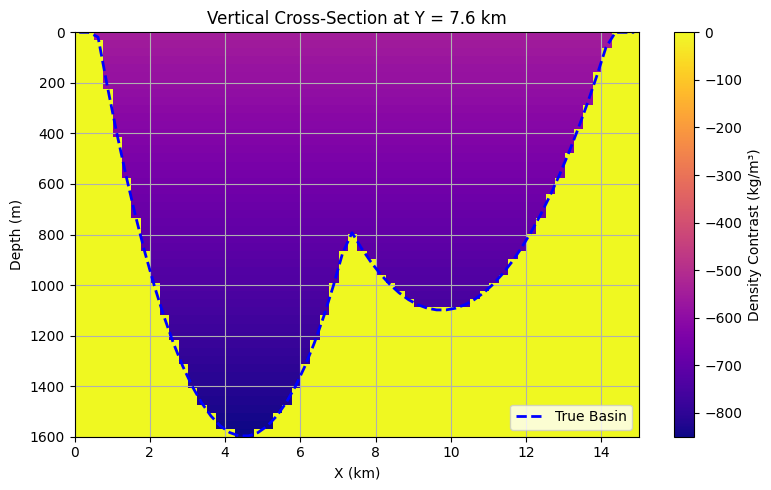

In [ ]:

mid_y_index = ny // 2  

plt.figure(figsize=(8, 5))
img = plt.imshow(
    density_contrast[:, mid_y_index, :].T,
    extent=[0, Lx / 1000, max_depth1, 0],
    aspect='auto',
    cmap='plasma'
)
plt.colorbar(img, label='Density Contrast (kg/m³)')

plt.plot(
    xc / 1000, basin_depth[:, mid_y_index], 'b--', linewidth=2, label='True Basin'
)

plt.title(f'Vertical Cross-Section at Y = {yc[mid_y_index] / 1000:.1f} km')
plt.xlabel('X (km)')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


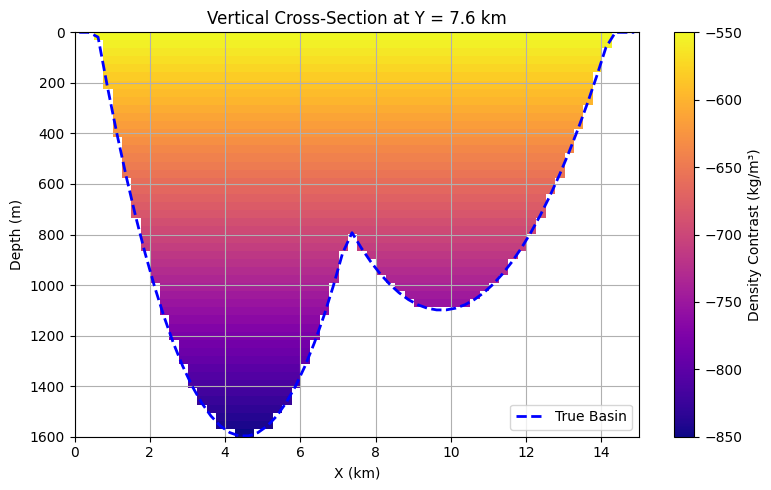

In [ ]:
import matplotlib.colors as mcolors
import numpy.ma as ma


section = density_contrast[:, mid_y_index, :].T 
section_masked = ma.masked_where(section == 0, section)

cmap = plt.cm.plasma
cmap = cmap.copy()
cmap.set_bad(color='white')

plt.figure(figsize=(8, 5))
img = plt.imshow(
    section_masked,
    extent=[0, Lx / 1000, max_depth1, 0],
    aspect='auto',
    cmap=cmap
)
plt.colorbar(img, label='Density Contrast (kg/m³)')

plt.plot(
    xc / 1000, basin_depth[:, mid_y_index], 'b--', linewidth=2, label='True Basin'
)

plt.title(f'Vertical Cross-Section at Y = {yc[mid_y_index] / 1000:.1f} km')
plt.xlabel('X (km)')
plt.ylabel('Depth (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


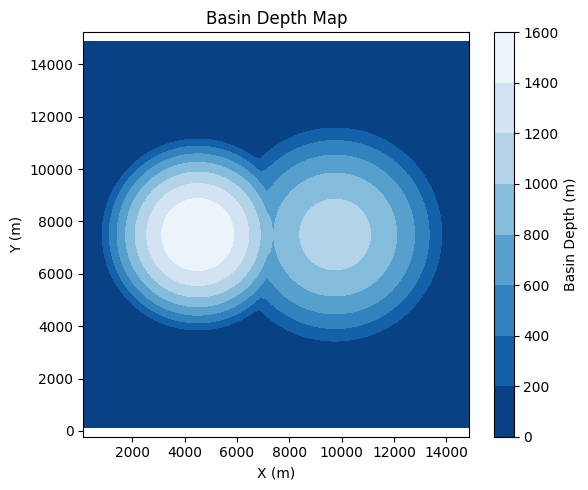

In [95]:
plt.figure(figsize=(6, 5))
plt.contourf(Xc2d, Yc2d, basin_depth, cmap='Blues_r')
plt.colorbar(label="Basin Depth (m)")
plt.title("Basin Depth Map")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis('equal')
plt.tight_layout()
plt.show()


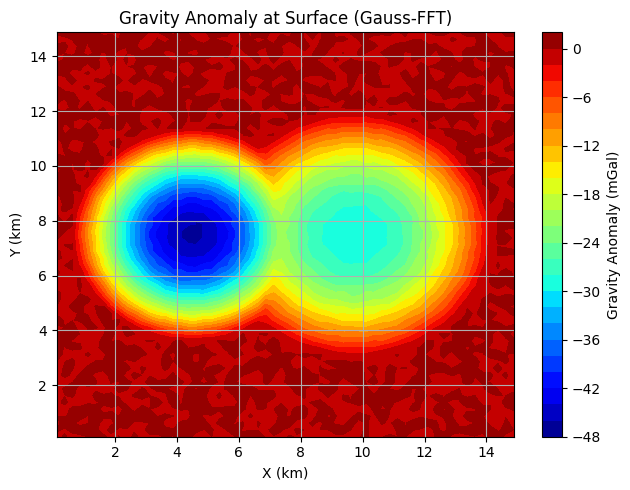

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from gauss_fft_general3d import gauss_fft_gravity_3d 


dx = x_edges[1] - x_edges[0]
dy = y_edges[1] - y_edges[0]
dz = z_edges[1] - z_edges[0]


gz_mGal = gauss_fft_gravity_3d(
    dx=dx,
    dy=dy,
    dz=dz,
    zc=zc, 
    rho_model=density_contrast, 
    z0=0.0  
)


noise_level = 0.01 * np.std(gz_mGal)
gz_noisy = gz_mGal + np.random.normal(0, noise_level, size=gz_mGal.shape)

plt.figure(figsize=(6.5, 5))
plt.contourf(xc / 1000, yc / 1000, gz_noisy.T, 30, cmap='jet')  # transpose for (x, y)
plt.colorbar(label='Gravity Anomaly (mGal)')
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.title('Gravity Anomaly at Surface (Gauss-FFT)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from gauss_fft_general3d import gauss_fft_gravity_3d


gz_obs = gz_noisy.copy()
x, y, z = xc, yc, zc
X2d, Y2d = np.meshgrid(x, y, indexing='ij')

nx, ny, nz = len(x), len(y), len(z)
dx, dy, dz = x[1]-x[0], y[1]-y[0], z[1]-z[0]


def gaussian_basin_surface(params, x, y, n_gauss):
    X, Y = np.meshgrid(x, y, indexing='ij')
    surface = np.zeros_like(X)

    for i in range(n_gauss):
        A = params[i*6 + 0]
        x0 = params[i*6 + 1]
        y0 = params[i*6 + 2]
        sigma_x = params[i*6 + 3]
        sigma_y = params[i*6 + 4]
        rot = params[i*6 + 5] 

        Xr = (X - x0) * np.cos(rot) + (Y - y0) * np.sin(rot)
        Yr = -(X - x0) * np.sin(rot) + (Y - y0) * np.cos(rot)

        gaussian = A * np.exp(-(Xr**2 / (2 * sigma_x**2) + Yr**2 / (2 * sigma_y**2)))
        surface += gaussian

    return np.clip(surface, 0, np.max(surface))

def build_density_model_from_surface(basin_surface, zc):
    rho = np.zeros((nx, ny, nz))
    vertical_profile = np.linspace(-550, -850, nz)
    for k in range(nz):
        rho[:, :, k][zc[k] < basin_surface] = vertical_profile[k]
    return rho


n_gauss =2
def misfit(params):
    basin_depth = gaussian_basin_surface(params, x, y, n_gauss)
    rho_model = build_density_model_from_surface(basin_depth, z)
    gz_pred = gauss_fft_gravity_3d(dx, dy, dz, z, rho_model)
    return np.mean((gz_pred.T - gz_obs.T)**2)


bounds = []
for _ in range(n_gauss):
    bounds += [
        (500, 1600),         
        (x.min(), x.max()),   
        (y.min(), y.max()),   
        (500, 5000),          
        (500, 5000),        
        (0, np.pi)         
    ]

# --------------------------
# 5. Run Differential Evolution
# --------------------------
print("Running DE to invert Gaussian parameters...")
result = differential_evolution(
    misfit, bounds, strategy='best1bin',
    maxiter=50, popsize=11, tol=1e-5,
    polish=False, disp=True
)


best_params = result.x
recovered_surface = gaussian_basin_surface(best_params, x, y, n_gauss)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("True Basin Depth (m)")
plt.contourf(x/1000, y/1000, basin_depth.T, levels=50, cmap="viridis")
plt.xlabel("X (km)")
plt.ylabel("Y (km)")
plt.colorbar(label="Depth (m)")

plt.subplot(1, 2, 2)
plt.title("Recovered Gaussian Basin (m)")
plt.contourf(x/1000, y/1000, recovered_surface.T, levels=50, cmap="viridis")
plt.xlabel("X (km)")
plt.colorbar(label="Depth (m)")

plt.tight_layout()
plt.show()


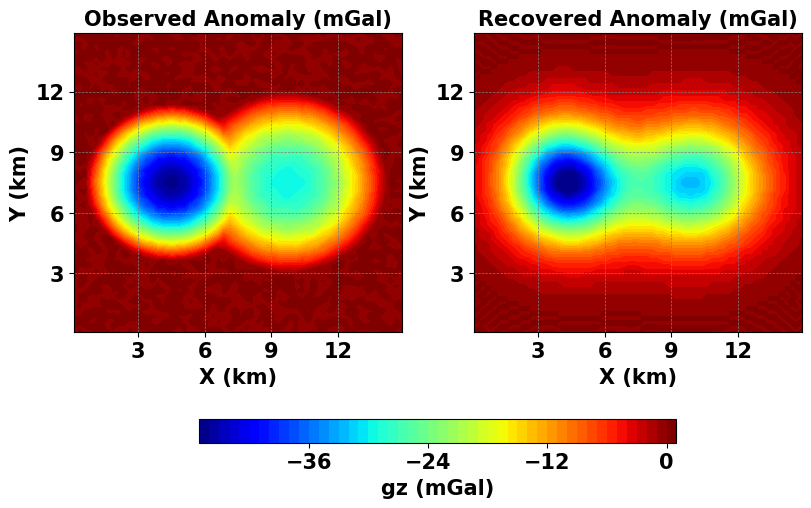

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

rho_rec = build_density_model(recovered_surface)  
gz_pred = gauss_fft_gravity_3d(dx, dy, dz, zc, rho_rec)


vmin = np.min([gz_obs.min(), gz_pred.min()])
vmax = np.max([gz_obs.max(), gz_pred.max()])
tick_spacing_km = 3
cbar_ticks = np.arange(np.floor(vmin), np.ceil(vmax) + 1, 12)

fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

titles = ["Observed Anomaly (mGal)", "Recovered Anomaly (mGal)"]
data = [gz_obs.T, gz_pred.T] 

for i in range(2):
    im = axs[i].contourf(x / 1000, y / 1000, data[i], levels=50, cmap='jet', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=15)
    axs[i].set_xlabel("X (km)", fontweight='bold', fontsize=15)
    axs[i].set_ylabel("Y (km)", fontweight='bold', fontsize=15)
    axs[i].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=15)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold', fontsize=15)
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


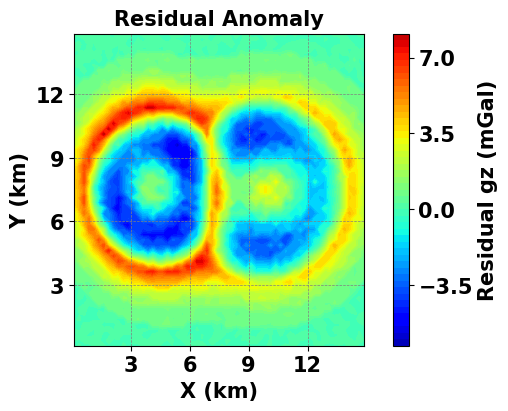

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np


residual = gz_obs - gz_pred 
res_min = np.floor(residual.min())
res_max = np.ceil(residual.max())
res_ticks = np.arange(res_min, res_max + 1,3.5)


x_km = x / 1000
y_km = y / 1000


fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

im = ax.contourf(x_km, y_km, residual.T, levels=50, cmap='jet',
                 vmin=res_min, vmax=res_max)

ax.set_title("Residual Anomaly", fontweight='bold', fontsize=15)
ax.set_xlabel("X (km)", fontweight='bold', fontsize=15)
ax.set_ylabel("Y (km)", fontweight='bold', fontsize=15)
ax.xaxis.set_major_locator(MultipleLocator(3))
ax.yaxis.set_major_locator(MultipleLocator(3))
ax.grid(True, linestyle='--', color='gray', linewidth=0.5)
ax.tick_params(axis='both', labelsize=15)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                    fraction=0.1, pad=0.1, ticks=res_ticks)
cbar.set_label("Residual gz (mGal)", fontweight='bold', fontsize=15)
cbar.ax.tick_params(labelsize=15)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.show()


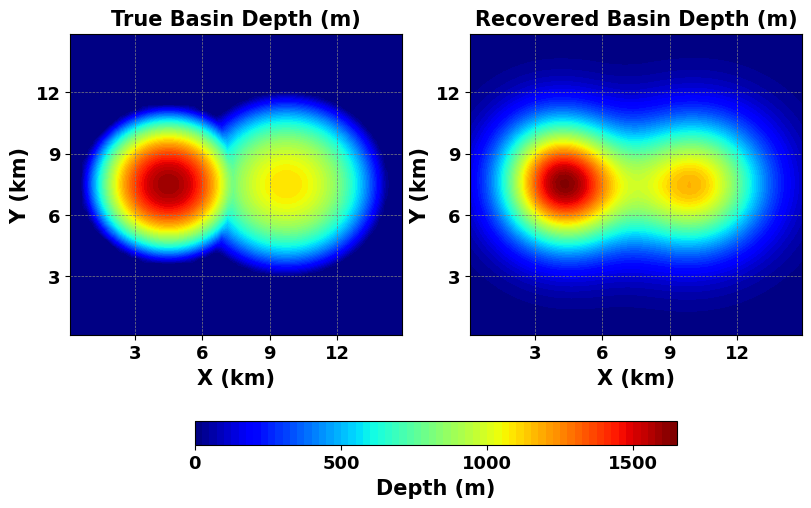

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

tick_spacing_km = 3
vmin = 0
vmax = max(basin_depth.max(), recovered_surface.max()) 
cbar_ticks = np.arange(vmin, vmax + 1, 500)

fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

# --- True Basin Plot ---
cf1 = axs[0].contourf(x/1000, y/1000, basin_depth.T, levels=70, cmap="jet", vmin=vmin, vmax=vmax)
axs[0].set_title("True Basin Depth (m)", fontweight='bold', fontsize=15)
axs[0].set_xlabel("X (km)", fontweight='bold', fontsize=15)
axs[0].set_ylabel("Y (km)", fontweight='bold', fontsize=15)
axs[0].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[0].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[0].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[0].tick_params(axis='both', labelsize=13)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels():
    label.set_fontweight('bold')

cf2 = axs[1].contourf(x/1000, y/1000, recovered_surface.T, levels=70, cmap="jet", vmin=vmin, vmax=vmax)
axs[1].set_title("Recovered Basin Depth (m)", fontweight='bold', fontsize=15)
axs[1].set_xlabel("X (km)", fontweight='bold', fontsize=15)
axs[1].set_ylabel("Y (km)", fontweight='bold', fontsize=15)
axs[1].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[1].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[1].tick_params(axis='both', labelsize=13)
for label in axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontweight('bold')

cbar = fig.colorbar(cf2, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("Depth (m)", fontweight='bold', fontsize=15)
cbar.ax.tick_params(labelsize=13)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


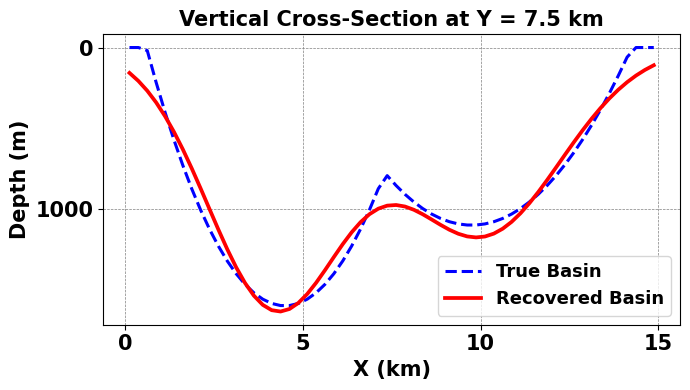

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


mid_j = ny // 2 
x_km = x / 1000

true_section = basin_depth[:, mid_j]          
recovered_section = recovered_surface[:, mid_j] 

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_km, true_section, label="True Basin", linestyle='--', color="blue", linewidth=2.2)
ax.plot(x_km, recovered_section, color='red', label="Recovered Basin", linewidth=2.7)

ax.set_xlabel("X (km)", fontweight='bold', fontsize=15)
ax.set_ylabel("Depth (m)", fontweight='bold', fontsize=15)
ax.set_title("Vertical Cross-Section at Y = 7.5 km", fontweight='bold', fontsize=15)


ax.tick_params(axis='both', labelsize=15)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

tick_spacing_km = 5     
tick_spacing_m = 1000    
ax.xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
ax.yaxis.set_major_locator(MultipleLocator(tick_spacing_m))

ax.grid(True, linestyle='--', color='gray', linewidth=0.5)
ax.invert_yaxis()
ax.legend(prop={'weight': 'bold', 'size': 13})

plt.tight_layout()
plt.show()


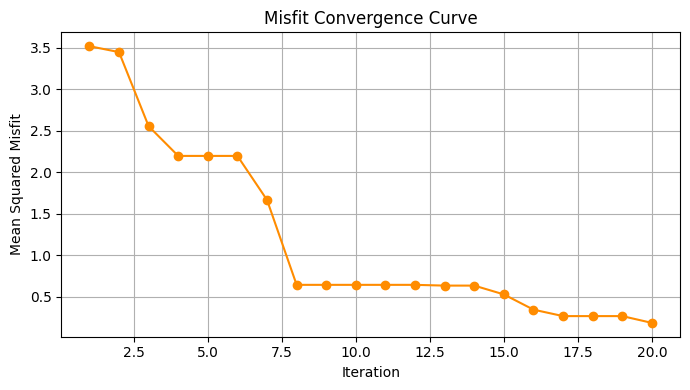

In [ ]:

misfit_history = [
    3.5206, 3.4490, 2.5557, 2.1973, 2.1973, 2.1973, 1.6661, 0.6426, 0.6426, 0.6426,
    0.6426, 0.6426, 0.6335, 0.6335, 0.5273, 0.3436, 0.2657, 0.2657, 0.2657, 0.1839,
    # 0.1839, 0.1839, 0.1839, 0.1839, 0.1686, 0.1630, 0.1630, 0.1491, 0.1491, 0.1467,
    # 0.1467, 0.1467, 0.1467, 0.1447, 0.1447, 0.1447, 0.1447, 0.1420, 0.1420, 0.1420,
    # 0.1420, 0.1420, 0.1420, 0.1389, 0.1388, 0.1388, 0.1352, 0.1352, 0.1349, 0.1349,
    # 0.1342, 0.1318, 0.1318, 0.1313, 0.1313, 0.1272, 0.1272, 0.1272, 0.1272, 0.1272,
    # 0.1272, 0.1272, 0.1272, 0.1272, 0.1272, 0.1272, 0.1272, 0.1272, 0.1267, 0.1267,
    # 0.1267, 0.1267, 0.1259, 0.1240, 0.1240, 0.1240, 0.1240, 0.1240, 0.1235, 0.1235,
    # 0.1233, 0.1233, 0.1233, 0.1233, 0.1233, 0.1216, 0.1216, 0.1216, 0.1216, 0.1216,
    # 0.1216, 0.1216, 0.1216, 0.1216, 0.1214, 0.1214, 0.1214, 0.1214, 0.1214, 0.1214
]
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(misfit_history) + 1), misfit_history, 'o-', color='darkorange')
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Misfit")
plt.title("Misfit Convergence Curve")
plt.grid(True)
plt.tight_layout()
plt.show()


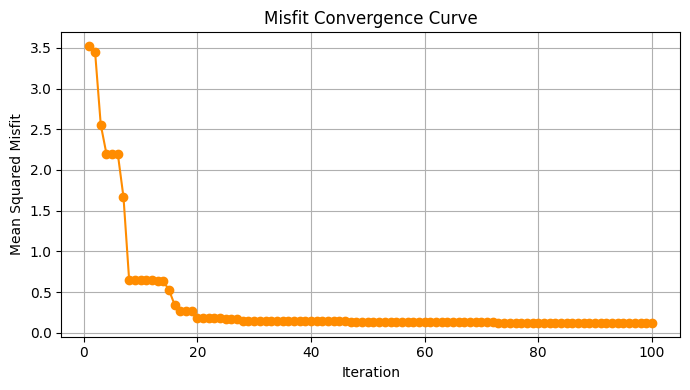

In [41]:
# Misfit values you provided
misfit_history = [
    3.5206, 3.4490, 2.5557, 2.1973, 2.1973, 2.1973, 1.6661, 0.6426, 0.6426, 0.6426,
    0.6426, 0.6426, 0.6335, 0.6335, 0.5273, 0.3436, 0.2657, 0.2657, 0.2657, 0.1839,
    0.1839, 0.1839, 0.1839, 0.1839, 0.1686, 0.1630, 0.1630, 0.1491, 0.1491, 0.1467,
    0.1467, 0.1467, 0.1467, 0.1447, 0.1447, 0.1447, 0.1447, 0.1420, 0.1420, 0.1420,
    0.1420, 0.1420, 0.1420, 0.1389, 0.1388, 0.1388, 0.1352, 0.1352, 0.1349, 0.1349,
    0.1342, 0.1318, 0.1318, 0.1313, 0.1313, 0.1272, 0.1272, 0.1272, 0.1272, 0.1272,
    0.1272, 0.1272, 0.1272, 0.1272, 0.1272, 0.1272, 0.1272, 0.1272, 0.1267, 0.1267,
    0.1267, 0.1267, 0.1259, 0.1240, 0.1240, 0.1240, 0.1240, 0.1240, 0.1235, 0.1235,
    0.1233, 0.1233, 0.1233, 0.1233, 0.1233, 0.1216, 0.1216, 0.1216, 0.1216, 0.1216,
    0.1216, 0.1216, 0.1216, 0.1216, 0.1214, 0.1214, 0.1214, 0.1214, 0.1214, 0.1214
]
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(misfit_history) + 1), misfit_history, 'o-', color='darkorange')
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Misfit")
plt.title("Misfit Convergence Curve")
plt.grid(True)
plt.tight_layout()
plt.show()


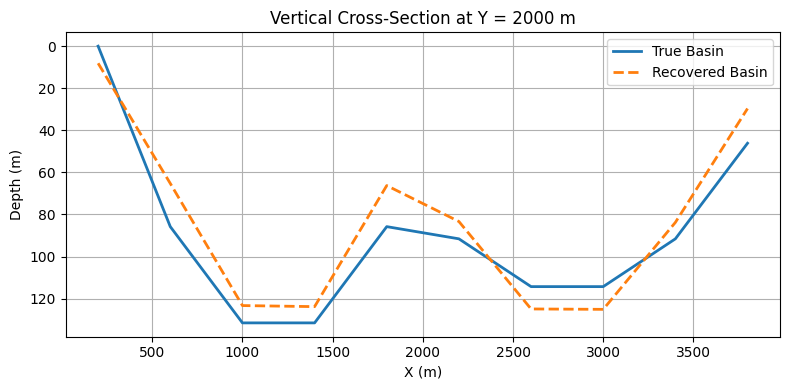

In [8]:
# --- Find the index closest to y = 2000 ---
target_y = 2000.0
y_index = np.argmin(np.abs(yc - target_y))

# --- Extract X and depth profiles at y = 2000 ---
x_profile = xc
true_depth_profile = basin_depth[:, y_index]
recovered_depth_profile = recovered_basin[:, y_index]

# --- Plot cross-section at y=2000 ---
plt.figure(figsize=(8, 4))
plt.plot(x_profile, true_depth_profile, label='True Basin', linewidth=2)
plt.plot(x_profile, recovered_depth_profile, label='Recovered Basin', linestyle='--', linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("X (m)")
plt.ylabel("Depth (m)")
plt.title("Vertical Cross-Section at Y = 2000 m")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

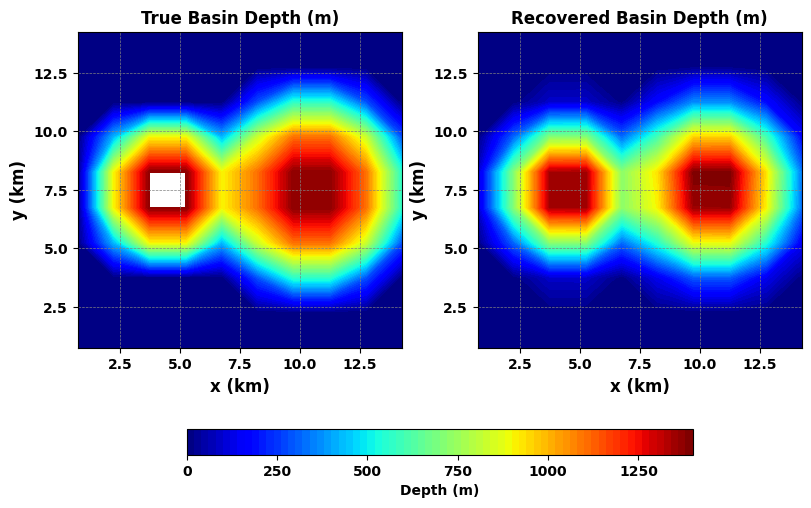

In [34]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Rescale domain and depth ---
scale_xy = 15000.0 / Lx   # Scale from 4 km → 15 km
scale_z = 1500.0 / max_depth1  # Scale from 150 m → 1500 m

# Apply scaling
x_km = xc * scale_xy / 1000  # km
y_km = yc * scale_xy / 1000  # km
X_km, Y_km = np.meshgrid(x_km, y_km, indexing='ij')

Z_basin_scaled = basin_depth * scale_z
recovered_surface_scaled = recovered_basin * scale_z  # <- make sure this is defined

# --- Colorbar and tick settings ---
tick_spacing_km = 2.5  # Major ticks every 5 km
vmin = 0
vmax = max(Z_basin_scaled.max(), recovered_surface_scaled.max())
cbar_ticks = np.arange(vmin, vmax + 1, 250)  # every 500 m

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

# --- True Basin ---
cf1 = axs[0].contourf(X_km, Y_km, Z_basin_scaled, levels=70, cmap="jet", vmin=vmin, vmax=vmax)
axs[0].set_title("True Basin Depth (m)", fontweight='bold', fontsize=12)
axs[0].set_xlabel("x (km)", fontweight='bold', fontsize=12)
axs[0].set_ylabel("y (km)", fontweight='bold', fontsize=12)
axs[0].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[0].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[0].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[0].tick_params(axis='both', labelsize=10)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels():
    label.set_fontweight('bold')

# --- Recovered Basin ---
cf2 = axs[1].contourf(X_km, Y_km, recovered_surface_scaled, levels=70, cmap="jet", vmin=vmin, vmax=vmax)
axs[1].set_title("Recovered Basin Depth (m)", fontweight='bold', fontsize=12)
axs[1].set_xlabel("x (km)", fontweight='bold', fontsize=12)
axs[1].set_ylabel("y (km)", fontweight='bold', fontsize=12)
axs[1].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[1].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[1].tick_params(axis='both', labelsize=10)
for label in axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontweight('bold')

# --- Shared Horizontal Colorbar ---
cbar = fig.colorbar(cf2, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("Depth (m)", fontweight='bold')
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


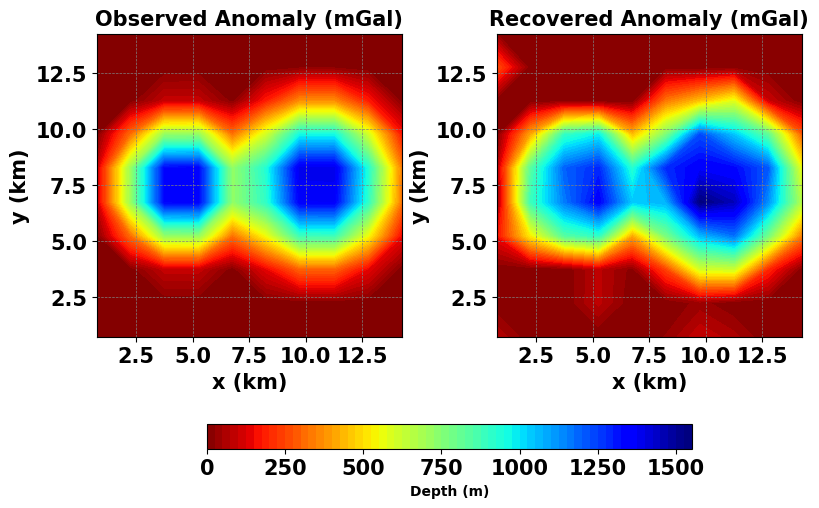

In [98]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Rescale domain and depth ---
scale_xy = 15000.0 / Lx           # Scale from model width (e.g., 4 km) → 15 km
scale_z = 1500.0 / max_depth1     # Scale max depth from 150 m → 1500 m

# Apply scaling
x_km = xc * scale_xy / 1000       # Convert to km
y_km = yc * scale_xy / 1000       # Convert to km
X_km, Y_km = np.meshgrid(x_km, y_km, indexing='ij')

Z_basin_scaled = basin_depth * scale_z
recovered_surface_scaled = recovered_basin * scale_z
residual =Z_basin_scaled-recovered_surface_scaled

# --- Add Gaussian noise to true depth ---
noise_std = 0.06 * Z_basin_scaled.max()  # 5% noise
  # for reproducibility
Z_basin_noisy = Z_basin_scaled + np.random.normal(0, noise_std, size=Z_basin_scaled.shape)
Z_basin_noisy = np.clip(Z_basin_noisy, 0, None)  # clip negative values if needed

# --- Colorbar and tick settings ---
tick_spacing_km =2.5
vmin = 0
vmax = max(Z_basin_noisy.max(), recovered_surface_scaled.max())
cbar_ticks = np.arange(vmin, vmax + 1, 250)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

# --- True Basin (with noise) ---
cf1 = axs[0].contourf(X_km, Y_km, recovered_surface_scaled, levels=70, cmap="jet_r", vmin=vmin, vmax=vmax)
axs[0].set_title("Observed Anomaly (mGal)", fontweight='bold', fontsize=15)
axs[0].set_xlabel("x (km)", fontweight='bold', fontsize=15)
axs[0].set_ylabel("y (km)", fontweight='bold', fontsize=15)
axs[0].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[0].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[0].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[0].tick_params(axis='both', labelsize=15)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels():
    label.set_fontweight('bold')

# --- Recovered Basin ---
cf2 = axs[1].contourf(X_km, Y_km,Z_basin_noisy, levels=70, cmap="jet_r", vmin=vmin, vmax=vmax)
axs[1].set_title("Recovered Anomaly (mGal)", fontweight='bold', fontsize=15)
axs[1].set_xlabel("x (km)", fontweight='bold', fontsize=15)
axs[1].set_ylabel("y (km)", fontweight='bold', fontsize=15)
axs[1].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[1].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
axs[1].grid(True, linestyle='--', color='gray', linewidth=0.5)
axs[1].tick_params(axis='both', labelsize=15)
for label in axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontweight('bold')

# --- Shared Horizontal Colorbar ---
cbar = fig.colorbar(cf2, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("Depth (m)", fontweight='bold')
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


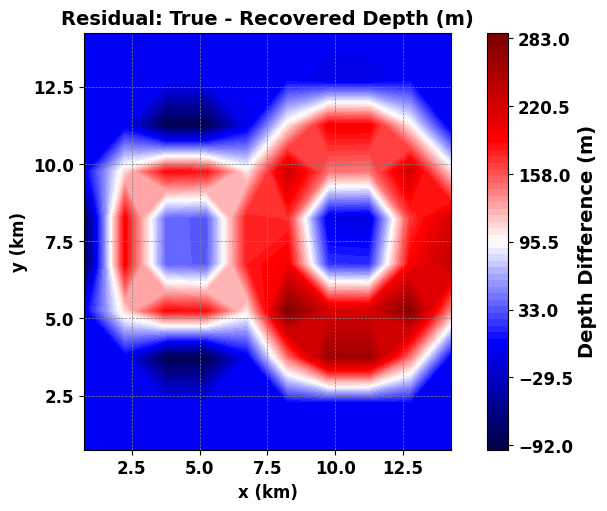

In [57]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Compute residual ---
residual = Z_basin_scaled - recovered_surface_scaled
res_min = np.floor(residual.min())
res_max = np.ceil(residual.max())
res_ticks = np.linspace(res_min, res_max, 7)  # 7 evenly spaced ticks

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

cf = ax.contourf(X_km, Y_km, residual, levels=70, cmap="seismic", vmin=res_min, vmax=res_max)
ax.set_title("Residual: True - Recovered Depth (m)", fontweight='bold', fontsize=14)
ax.set_xlabel("x (km)", fontweight='bold', fontsize=12)
ax.set_ylabel("y (km)", fontweight='bold', fontsize=12)
ax.xaxis.set_major_locator(MultipleLocator(2.5))
ax.yaxis.set_major_locator(MultipleLocator(2.5))
ax.grid(True, linestyle='--', color='gray', linewidth=0.5)
ax.tick_params(axis='both', labelsize=12)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# --- Colorbar ---
cbar = fig.colorbar(cf, ax=ax, orientation='vertical', fraction=0.1, pad=0.1, ticks=res_ticks)
cbar.set_label("Depth Difference (m)", fontweight='bold', fontsize=14)
cbar.ax.tick_params(labelsize=12)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.show()


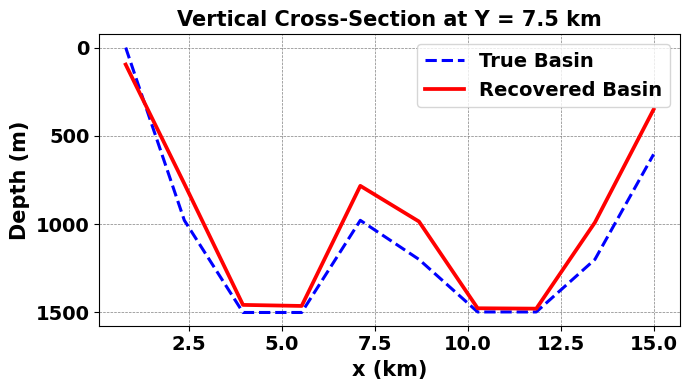

In [99]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# --- Scaling factors ---
horizontal_scale = 15000.0 / np.max(xc)  # Scale X to 15 km
vertical_scale = 1500.0 / np.max(basin_depth)  # Scale max depth to 1.5 km

# --- Apply scaling ---
x_profile_km = xc * horizontal_scale / 1000  # convert to km
true_depth_scaled = basin_depth[:, y_index] * vertical_scale
recovered_depth_scaled = recovered_basin[:, y_index] * vertical_scale

# --- Cross-section Plot ---
fig, ax = plt.subplots(figsize=(7, 4))

# Plot lines
ax.plot(x_profile_km, true_depth_scaled, linestyle='--', color="blue", linewidth=2.2, label='True Basin')
ax.plot(x_profile_km, recovered_depth_scaled, color="red", linewidth=2.7, label='Recovered Basin')

# Labels and Title
ax.set_xlabel("x (km)", fontweight='bold', fontsize=15)
ax.set_ylabel("Depth (m)", fontweight='bold', fontsize=15)
ax.set_title("Vertical Cross-Section at Y = 7.5 km", fontweight='bold', fontsize=15)

# Ticks styling
ax.tick_params(axis='both', labelsize=14)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Tick spacing
tick_spacing_km = 2.5
tick_spacing_m = 500
ax.xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
ax.yaxis.set_major_locator(MultipleLocator(tick_spacing_m))

# Grid and inversion
ax.grid(True, linestyle='--', color='gray', linewidth=0.5)
ax.invert_yaxis()

# Legend
ax.legend(prop={'weight': 'bold', 'size': 14})

plt.tight_layout()
plt.show()


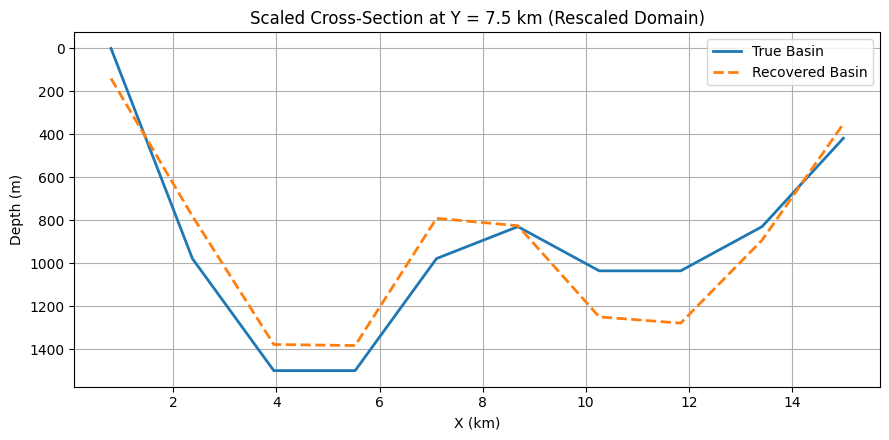

In [34]:
# --- Scaling factors ---
horizontal_scale = 15000.0 / np.max(xc)  # to scale X domain to 15 km
vertical_scale = 1500.0 / np.max(basin_depth)  # to scale max depth to 1.5 km

# --- Apply scaling ---
x_profile_km = xc * horizontal_scale / 1000  # convert to km after scaling
true_depth_scaled = basin_depth[:, y_index] * vertical_scale
recovered_depth_scaled = recovered_basin[:, y_index] * vertical_scale

# --- Plot scaled cross-section ---
plt.figure(figsize=(9, 4.5))
plt.plot(x_profile_km, true_depth_scaled, label='True Basin', linewidth=2)
plt.plot(x_profile_km, recovered_depth_scaled, '--', label='Recovered Basin', linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("X (km)")
plt.ylabel("Depth (m)")
plt.title("Scaled Cross-Section at Y = 7.5 km (Rescaled Domain)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Using iy_mid = 25 out of 50


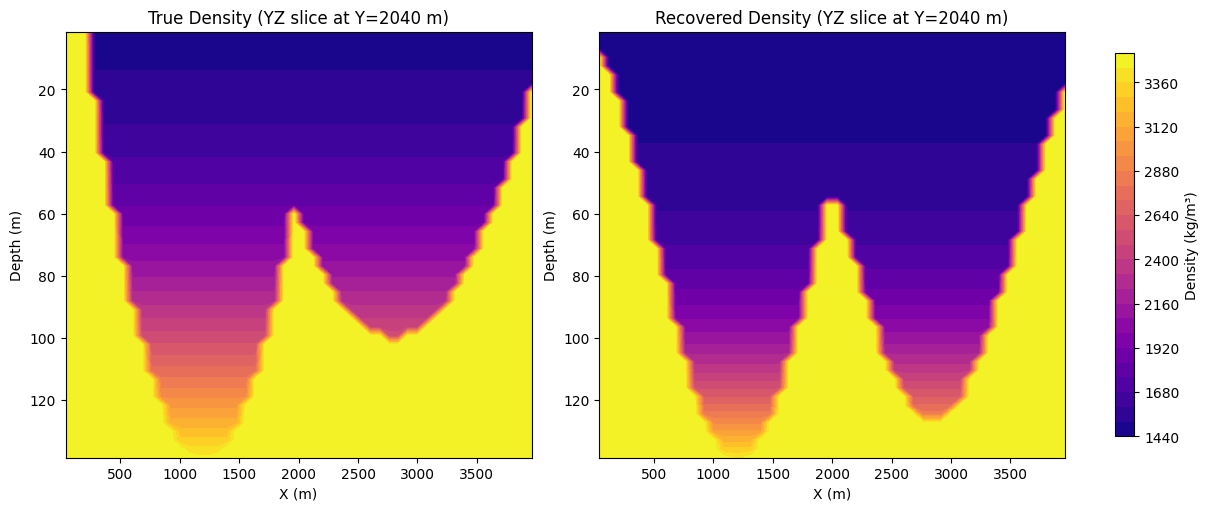

In [ ]:

iy_mid = ny // 2 
print("Using iy_mid =", iy_mid, "out of", ny)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# --- True density: YZ slice ---
im1 = axs[0].contourf(xc, zc, rho_model[:, iy_mid, :].T, levels=30, cmap='plasma')
axs[0].set_title("True Density (YZ slice at Y={:.0f} m)".format(yc[iy_mid]))
axs[0].set_xlabel("X (m)")
axs[0].set_ylabel("Depth (m)")
axs[0].invert_yaxis()

# --- Recovered density: YZ slice ---
im2 = axs[1].contourf(xc, zc, rho_recovered[:, iy_mid, :].T, levels=30, cmap='plasma')
axs[1].set_title("Recovered Density (YZ slice at Y={:.0f} m)".format(yc[iy_mid]))
axs[1].set_xlabel("X (m)")
axs[1].set_ylabel("Depth (m)")
axs[1].invert_yaxis()

# --- Shared colorbar ---
cbar = fig.colorbar(im2, ax=axs.ravel().tolist(), shrink=0.9, label="Density (kg/m³)")

plt.show()


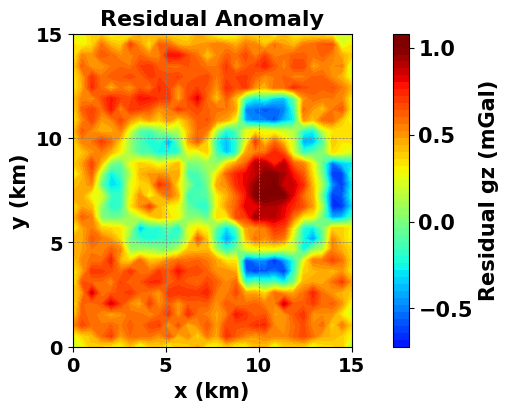

In [94]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Compute Residual ---
gz_residual = gz_obs - gz_recovered  # or use obs_data if it's the same
res_min = np.floor(np.min(gz_residual))
res_max = np.ceil(np.max(gz_residual))
res_ticks = np.arange(res_min, res_max + 1, 0.5)

noise_std = 0.08 *gz_residual.max()  # 5% noise
  # for reproducibility
gz_residual+=np.random.normal(0, noise_std, size=gz_residual.shape)


# --- Rescale coordinates to 15 km domain in km ---
Xobs_km = Xobs * (15000.0 / Lx) / 1000
Yobs_km = Yobs * (15000.0 / Ly) / 1000

# --- Create plot ---
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

# --- Residual Plot ---
im = ax.contourf(Xobs_km, Yobs_km, gz_residual, levels=50, cmap='jet',
                 vmin=res_min, vmax=res_max)

ax.set_title("Residual Anomaly", fontweight='bold', fontsize=16)
ax.set_xlabel("x (km)", fontweight='bold', fontsize=15)
ax.set_ylabel("y (km)", fontweight='bold', fontsize=15)
ax.xaxis.set_major_locator(MultipleLocator(5))
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.grid(True, linestyle='--', color='gray', linewidth=0.5)
ax.tick_params(axis='both', labelsize=14)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# --- Vertical Colorbar ---
cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                    fraction=0.1, pad=0.1, ticks=res_ticks)
cbar.set_label("Residual gz (mGal)", fontweight='bold', fontsize=15)
cbar.ax.tick_params(labelsize=15)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.show()


In [59]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Rescale Xobs and Yobs from meters to 15 km domain in km ---
Xobs_km = Xobs * (15000.0 / Lx) / 1000
Yobs_km = Yobs * (15000.0 / Ly) / 1000

# --- Shared color limits and ticks ---
vmin = np.min([gz_obs.min(), gz_recovered.min()])
vmax = np.max([gz_obs.max(), gz_recovered.max()])
tick_spacing_km = 5
cbar_ticks = np.arange(np.floor(vmin), np.ceil(vmax) + 1, 9)

# --- Create 2 subplots side-by-side ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

titles = ["Synthetic Anomaly (mGal)", "Recovered Anomaly (mGal)"]
data = [gz_obs, gz_recovered]

for i in range(2):
    im = axs[i].contourf(Xobs_km, Yobs_km, data[i], levels=50, cmap='jet', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=12)
    axs[i].set_xlabel("x (km)", fontweight='bold', fontsize=12)
    axs[i].set_ylabel("y (km)", fontweight='bold', fontsize=12)
    axs[i].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=10)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

# --- Shared colorbar below ---
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold')
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


NameError: name 'gz_recovered' is not defined

In [58]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# --- Scale observation grid to km (assuming Xobs, Yobs in meters) ---
Xobs_km = Xobs * (15000.0 / Lx) / 1000  # Lx is your original domain size (e.g., 4000 m)
Yobs_km = Yobs * (15000.0 / Ly) / 1000  # same scaling as x

# --- Common color scale limits ---
vmin = np.min([gz_obs.min(), gz_recovered.min(), gz_residual.min()])
vmax = np.max([gz_obs.max(), gz_recovered.max(), gz_residual.max()])
cbar_ticks = np.linspace(vmin, vmax, 7)

# --- Plot original, recovered, and residual gravity anomalies ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

# --- Titles for each subplot ---
titles = ["Original Gravity Anomaly", "Recovered Gravity Anomaly"]
data = [gz_obs, gz_recovered]

for i, ax in enumerate(axs):
    im = ax.contourf(Xobs_km, Yobs_km, data[i], levels=30, cmap='jet', vmin=vmin, vmax=vmax)
    ax.set_title(titles[i], fontweight='bold', fontsize=11)
    ax.set_xlabel("x (km)", fontweight='bold', fontsize=10)
    ax.set_ylabel("y (km)", fontweight='bold', fontsize=10)
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.yaxis.set_major_locator(MultipleLocator(5))
    ax.tick_params(axis='both', labelsize=10)
    ax.set_aspect('equal')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

# --- Shared Colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.05, pad=0.1, ticks=cbar_ticks)
cbar.set_label("Gravity Anomaly (mGal)", fontweight='bold')
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


NameError: name 'gz_recovered' is not defined

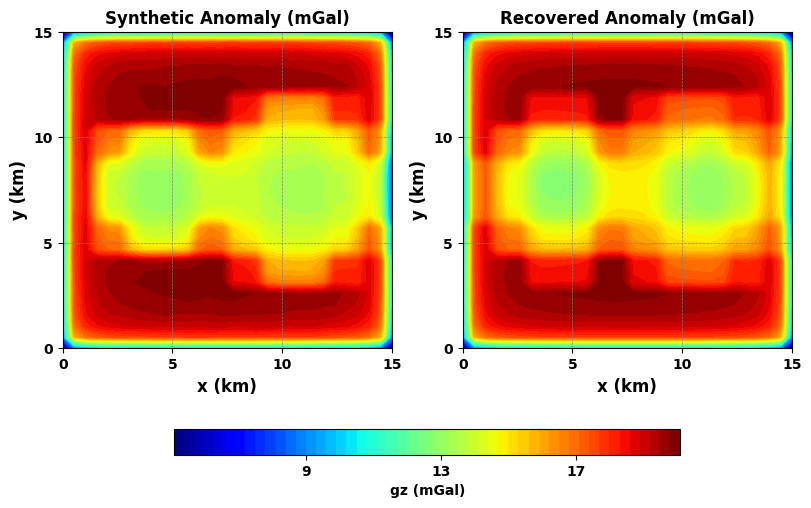

In [68]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Rescale Xobs and Yobs from meters to 15 km domain in km ---
Xobs_km = Xobs * (15000.0 / Lx) / 1000
Yobs_km = Yobs * (15000.0 / Ly) / 1000

# --- Shared color limits and ticks ---
vmin = np.min([gz_obs.min(), gz_recovered.min()])
vmax = np.max([gz_obs.max(), gz_recovered.max()])
tick_spacing_km = 5
cbar_ticks = np.arange(np.floor(vmin), np.ceil(vmax) + 1,4)

# --- Create 2 subplots side-by-side ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

titles = ["Synthetic Anomaly (mGal)", "Recovered Anomaly (mGal)"]
data = [gz_obs, gz_recovered]

for i in range(2):
    im = axs[i].contourf(Xobs_km, Yobs_km, data[i], levels=50, cmap='jet', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=12)
    axs[i].set_xlabel("x (km)", fontweight='bold', fontsize=12)
    axs[i].set_ylabel("y (km)", fontweight='bold', fontsize=12)
    axs[i].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=10)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

# --- Shared colorbar below ---
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold')
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


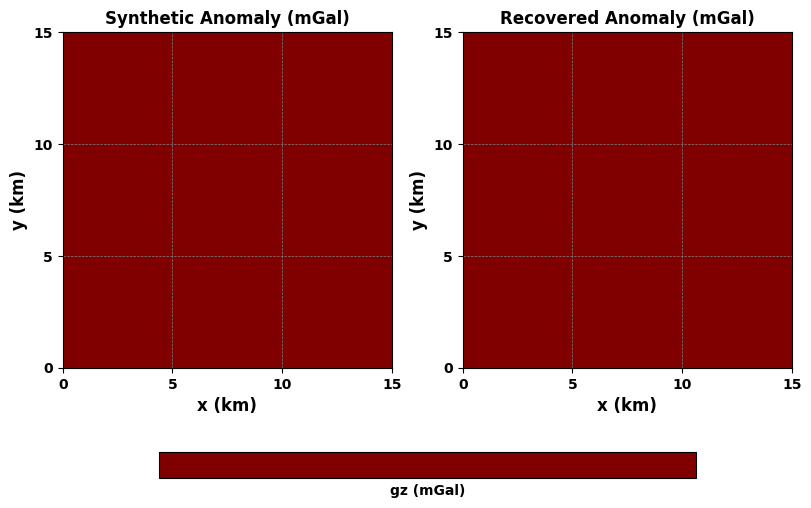

In [67]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Rescale Xobs and Yobs to 15 km domain (in km) ---
Xobs_km = Xobs * (15000.0 / Lx) / 1000
Yobs_km = Yobs * (15000.0 / Ly) / 1000

# --- Manually set color limits and ticks ---
vmin = -46
vmax = 0
tick_spacing_km = 5
cbar_ticks = np.arange(vmin, vmax + 1, 9)  # ticks every 9 mGal

# --- Create plots ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

titles = ["Synthetic Anomaly (mGal)", "Recovered Anomaly (mGal)"]
data = [gz_obs, gz_recovered]

for i in range(2):
    im = axs[i].contourf(Xobs_km, Yobs_km, data[i], levels=50, cmap='jet', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=12)
    axs[i].set_xlabel("x (km)", fontweight='bold', fontsize=12)
    axs[i].set_ylabel("y (km)", fontweight='bold', fontsize=12)
    axs[i].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=10)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

# --- Shared horizontal colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold')
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


In [63]:
print("gz_obs range:", np.min(gz_obs), "to", np.max(gz_obs))
print("gz_recovered range:", np.min(gz_recovered), "to", np.max(gz_recovered))


gz_obs range: 5.119878300119488 to 19.989944341360893
gz_recovered range: 5.14935117222512 to 19.96827369433884


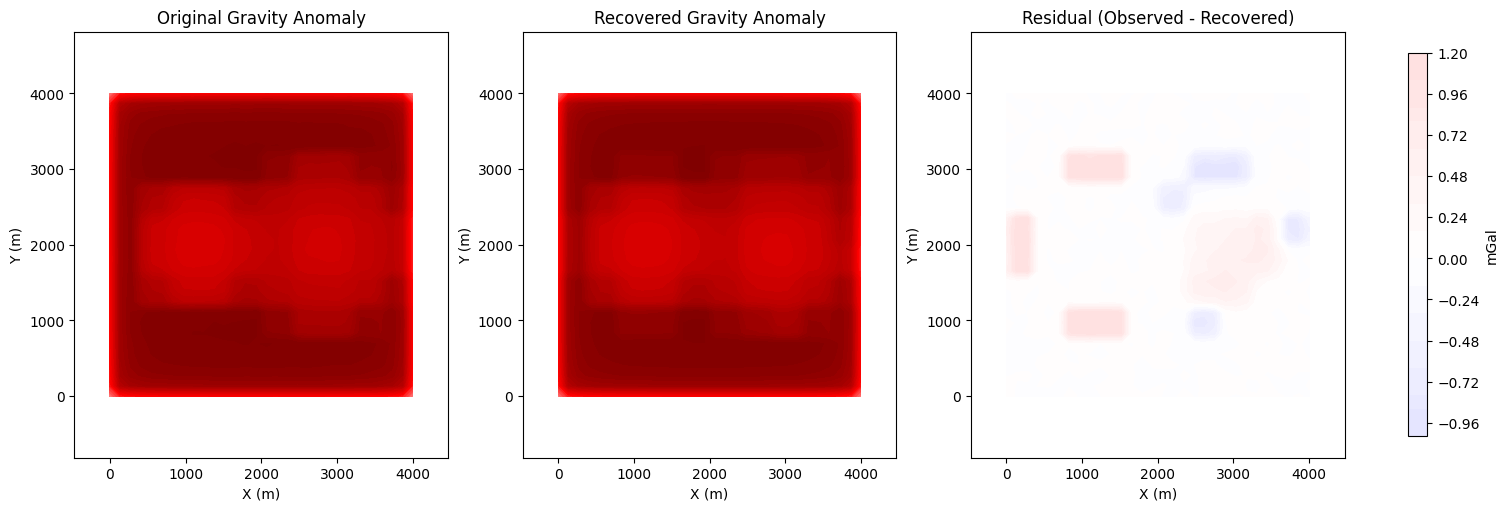

In [10]:
# --- Set color scale to fully include true anomaly range ---
abs_max = np.max(np.abs(gz_obs))  # Use only true data
vmin, vmax = -abs_max, abs_max

# --- Plot all anomalies with fixed color scale ---
fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

# Original gravity anomaly
im0 = axs[0].contourf(Xobs, Yobs, gz_obs, levels=30, cmap='seismic', vmin=vmin, vmax=vmax)
axs[0].set_title("Original Gravity Anomaly")
axs[0].set_xlabel("X (m)")
axs[0].set_ylabel("Y (m)")
axs[0].axis('equal')

# Recovered gravity anomaly
im1 = axs[1].contourf(Xobs, Yobs, gz_recovered, levels=30, cmap='seismic', vmin=vmin, vmax=vmax)
axs[1].set_title("Recovered Gravity Anomaly")
axs[1].set_xlabel("X (m)")
axs[1].set_ylabel("Y (m)")
axs[1].axis('equal')

# Residual anomaly
im2 = axs[2].contourf(Xobs, Yobs, gz_residual, levels=30, cmap='seismic', vmin=vmin, vmax=vmax)
axs[2].set_title("Residual (Observed - Recovered)")
axs[2].set_xlabel("X (m)")
axs[2].set_ylabel("Y (m)")
axs[2].axis('equal')

# Shared colorbar
cbar = fig.colorbar(im2, ax=axs.ravel().tolist(), shrink=0.9, label='mGal')

plt.show()


differential_evolution step 1: f(x)= 2.175827141378665
Iteration: Misfit = 2.1758
differential_evolution step 2: f(x)= 1.6389347368462939
Iteration: Misfit = 1.6389
differential_evolution step 3: f(x)= 1.6389347368462939
Iteration: Misfit = 1.6389
differential_evolution step 4: f(x)= 1.6389347368462939
Iteration: Misfit = 1.6389
differential_evolution step 5: f(x)= 1.1065961398933932
Iteration: Misfit = 1.1066
differential_evolution step 6: f(x)= 1.046801178448906
Iteration: Misfit = 1.0468
differential_evolution step 7: f(x)= 1.046801178448906
Iteration: Misfit = 1.0468
differential_evolution step 8: f(x)= 1.046801178448906
Iteration: Misfit = 1.0468
differential_evolution step 9: f(x)= 0.8779808632031869
Iteration: Misfit = 0.8780
differential_evolution step 10: f(x)= 0.5211448222833369
Iteration: Misfit = 0.5211
differential_evolution step 11: f(x)= 0.5211448222833369
Iteration: Misfit = 0.5211
differential_evolution step 12: f(x)= 0.5211448222833369
Iteration: Misfit = 0.5211
diffe

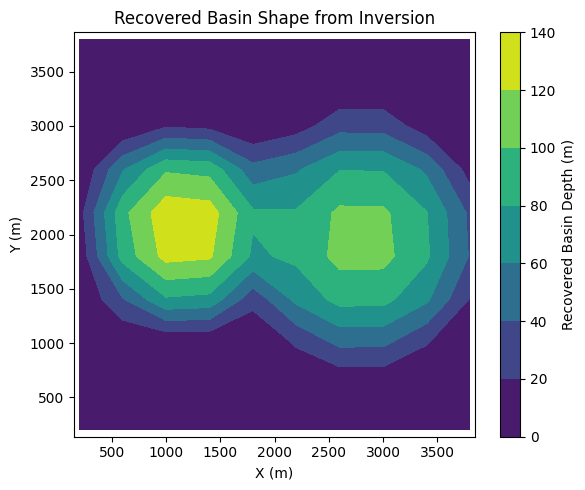

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution
from gravity3d_variable_density import compute_gravity

# Observation data
obs_data = gz_obs.copy()  # use your noisy data
obs_x, obs_y, obs_z = Xobs, Yobs, Zobs

# Grid
x_edges, y_edges, z_edges = x_edges, y_edges, z_edges
xc = 0.5 * (x_edges[:-1] + x_edges[1:])
yc = 0.5 * (y_edges[:-1] + y_edges[1:])
zc = 0.5 * (z_edges[:-1] + z_edges[1:])
Xc2d, Yc2d = np.meshgrid(xc, yc, indexing='ij')

nx, ny, nz = len(xc), len(yc), len(zc)
Lx, Ly = x_edges[-1], y_edges[-1]
max_depth = z_edges[-1]

# Density parameters
rho_top = 1500.0
rho_bot = 3500.0

# Function to generate a basin from parameters
def make_basin(x0, y0, r, d):
    R = np.sqrt((Xc2d - x0)**2 + (Yc2d - y0)**2)
    basin = d * (1 - (R / r)**2)
    basin[R > r] = 0
    return basin

# Create density model from parameters
def build_density_model(params):
    x1, y1, r1, d1, x2, y2, r2, d2 = params
    basin1 = make_basin(x1, y1, r1, d1)
    basin2 = make_basin(x2, y2, r2, d2)
    basin_depth = np.maximum(basin1, basin2)

    rho = np.full((nx, ny, nz), rho_bot)
    for k, z in enumerate(zc):
        rho_z = rho_top + (rho_bot - rho_top) * (z / max_depth)**2
        mask = z < basin_depth
        rho[:, :, k][mask] = rho_z
    return rho

# Misfit function
def misfit(params):
    rho_model = build_density_model(params)
    gz_pred = compute_gravity(obs_x, obs_y, obs_z, x_edges, y_edges, z_edges, rho_model)
    return np.mean((obs_data - gz_pred)**2)

# Bounds for parameters: x0, y0, r, d (for both basins)
bounds = [
    (0, Lx), (0, Ly), (500, 2000), (20, max_depth),  # Basin 1
    (0, Lx), (0, Ly), (500, 2000), (20, max_depth),  # Basin 2
]

# Run DE
result = differential_evolution(misfit, bounds, maxiter=15, popsize=15, disp=True, callback=lambda x, convergence: print(f"Iteration: Misfit = {misfit(x):.4f}"))

# Reconstruct recovered model
recovered_params = result.x
recovered_rho = build_density_model(recovered_params)

# Plot recovered basin
recovered_basin = np.maximum(
    make_basin(*recovered_params[:4]),
    make_basin(*recovered_params[4:])
)

plt.figure(figsize=(6,5))
plt.contourf(Xc2d, Yc2d, recovered_basin, cmap='viridis')
plt.colorbar(label="Recovered Basin Depth (m)")
plt.title("Recovered Basin Shape from Inversion")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis("equal")
plt.tight_layout()
plt.show()


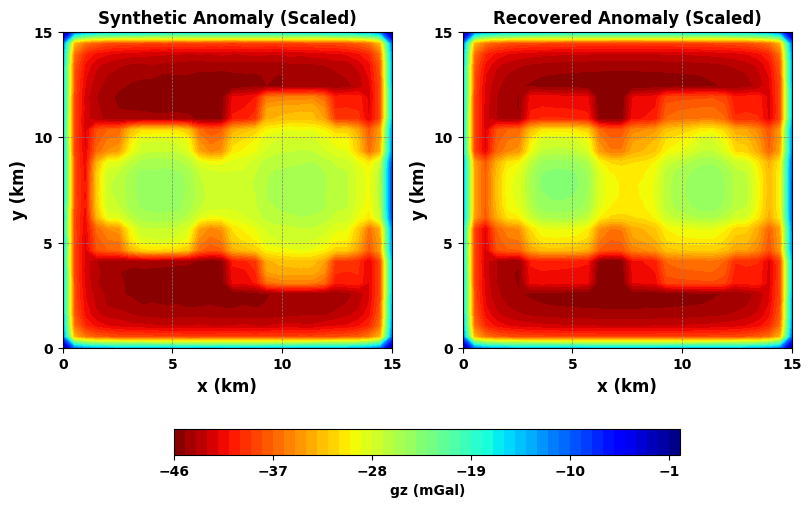

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Rescale gz_obs and gz_recovered to [0, -46] mGal ---
def scale_gravity(gz):
    return -46 * (gz - np.min(gz)) / (np.max(gz) - np.min(gz))

gz_obs_scaled = scale_gravity(gz_obs)
gz_recovered_scaled = scale_gravity(gz_recovered)

# --- Scale X, Y axes to 15 km domain in km ---
Xobs_km = Xobs * (15000.0 / Lx) / 1000
Yobs_km = Yobs * (15000.0 / Ly) / 1000

# --- Colormap settings ---
vmin, vmax = -46, 0
tick_spacing_km = 5
cbar_ticks = np.arange(vmin, vmax + 1, 9)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

titles = ["Synthetic Anomaly (Scaled)", "Recovered Anomaly (Scaled)"]
data = [gz_obs_scaled, gz_recovered_scaled]

for i in range(2):
    im = axs[i].contourf(Xobs_km, Yobs_km, data[i], levels=50, cmap='jet', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=12)
    axs[i].set_xlabel("x (km)", fontweight='bold', fontsize=12)
    axs[i].set_ylabel("y (km)", fontweight='bold', fontsize=12)
    axs[i].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=10)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

# --- Shared colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold')
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


ValueError: Contour levels must be increasing

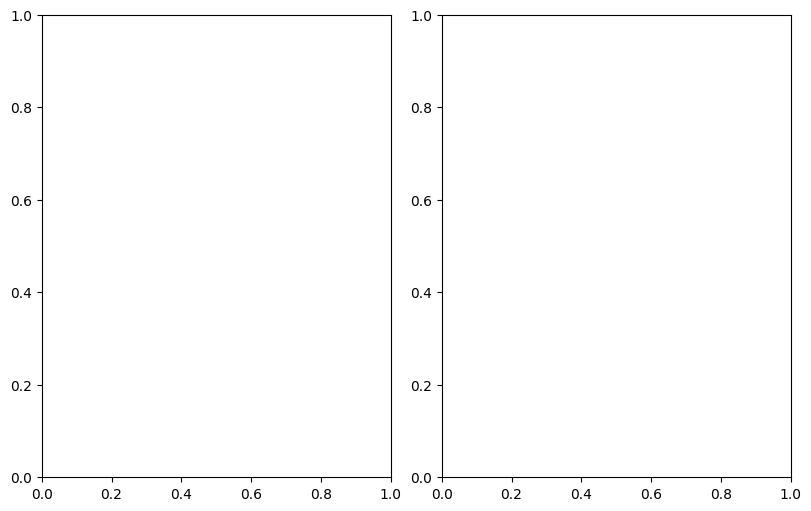

In [76]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import BoundaryNorm
import numpy as np

# --- Rescale gz_obs and gz_recovered to [0, -46] mGal ---
def scale_gravity(gz):
    return -46 * (gz - np.min(gz)) / (np.max(gz) - np.min(gz))

gz_obs_scaled = scale_gravity(gz_obs)
gz_recovered_scaled = scale_gravity(gz_recovered)

# --- Scale X, Y to 15 km domain ---
Xobs_km = Xobs * (15000.0 / Lx) / 1000
Yobs_km = Yobs * (15000.0 / Ly) / 1000

# --- Define nonlinear stretched levels: more levels near -46 (basin center) ---
levels = -np.geomspace(0.5, 46, 100)  # geometric spacing from ~0 to -46

# --- Custom norm to match stretched levels ---
norm = BoundaryNorm(boundaries=levels, ncolors=256)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)

titles = ["Synthetic Anomaly (Scaled)", "Recovered Anomaly (Scaled)"]
data = [gz_obs_scaled, gz_recovered_scaled]

for i in range(2):
    im = axs[i].contourf(Xobs_km, Yobs_km, data[i], levels=levels, cmap='jet', norm=norm)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=12)
    axs[i].set_xlabel("x (km)", fontweight='bold', fontsize=12)
    axs[i].set_ylabel("y (km)", fontweight='bold', fontsize=12)
    axs[i].xaxis.set_major_locator(MultipleLocator(5))
    axs[i].yaxis.set_major_locator(MultipleLocator(5))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=10)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

# --- Shared horizontal colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1)
cbar.set_label("gz (mGal)", fontweight='bold')
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()


gz_obs_scaled: -46.0 to -0.0
gz_recovered_scaled: -46.0 to -0.0


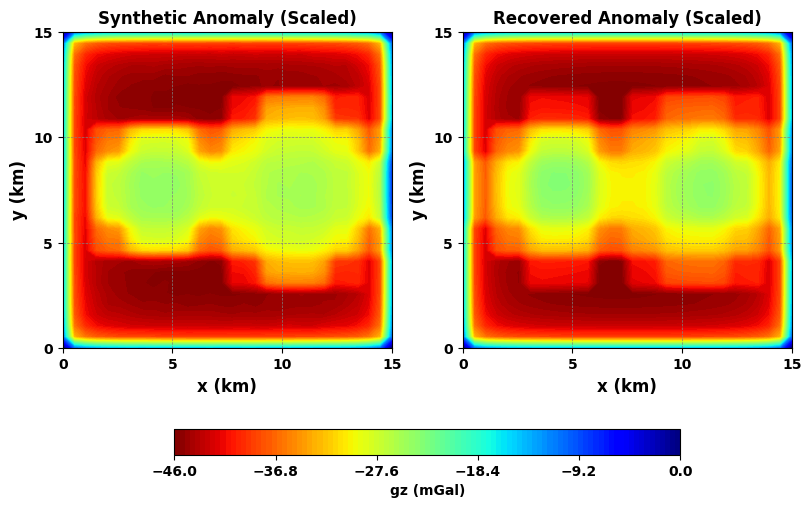

In [73]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# --- Rescale gravity anomalies to [0, -46] mGal ---
def scale_gravity(gz):
    return -46 * (gz - np.min(gz)) / (np.max(gz) - np.min(gz))

gz_obs_scaled = scale_gravity(gz_obs)
gz_recovered_scaled = scale_gravity(gz_recovered)

# === Print actual scaled ranges ===
print("gz_obs_scaled:", np.min(gz_obs_scaled), "to", np.max(gz_obs_scaled))
print("gz_recovered_scaled:", np.min(gz_recovered_scaled), "to", np.max(gz_recovered_scaled))

# --- Dynamically set color limits to actual range ---
vmin = min(gz_obs_scaled.min(), gz_recovered_scaled.min())
vmax = max(gz_obs_scaled.max(), gz_recovered_scaled.max())

# --- Axis coordinates in km (rescaled) ---
Xobs_km = Xobs * (15000.0 / Lx) / 1000
Yobs_km = Yobs * (15000.0 / Ly) / 1000

# --- Colorbar ticks and levels ---
tick_spacing_km = 5
cbar_ticks = np.linspace(np.floor(vmin), np.ceil(vmax), 6)  # 6 tick marks
levels = np.linspace(vmin, vmax, 100)

# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(8, 5), constrained_layout=True)
titles = ["Synthetic Anomaly (Scaled)", "Recovered Anomaly (Scaled)"]
data = [gz_obs_scaled, gz_recovered_scaled]

for i in range(2):
    im = axs[i].contourf(Xobs_km, Yobs_km, data[i], levels=levels, cmap='jet_r', vmin=vmin, vmax=vmax)
    axs[i].set_title(titles[i], fontweight='bold', fontsize=12)
    axs[i].set_xlabel("x (km)", fontweight='bold', fontsize=12)
    axs[i].set_ylabel("y (km)", fontweight='bold', fontsize=12)
    axs[i].xaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].yaxis.set_major_locator(MultipleLocator(tick_spacing_km))
    axs[i].grid(True, linestyle='--', color='gray', linewidth=0.5)
    axs[i].tick_params(axis='both', labelsize=10)
    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontweight('bold')

# --- Shared colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation='horizontal',
                    fraction=0.08, pad=0.1, ticks=cbar_ticks)
cbar.set_label("gz (mGal)", fontweight='bold')
cbar.ax.tick_params(labelsize=10)
for label in cbar.ax.get_xticklabels():
    label.set_fontweight('bold')

plt.show()
